In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif']=['simHei']


In [ ]:
df = pd.read_csv('ai_tools_capability_ranking.csv')

In [ ]:
print('数据行数：',len(df))#数据行数
print('数据列数：',len(df.columns))#数据列数
print('数据预览：',df.head(1))#数据预览
#print('数据统计信息：',df.describe())#数据统计信息
#print('数据缺失值统计：',df.isnull().sum())#数据缺失值统计
#print('数据重复行数：',df.duplicated().sum())#数据重复行数


In [ ]:
# 数据清洗步骤1：删除"公司成立日期 Company_Founding_Date"列
# errors='ignore' 的作用：重复运行这个单元格也不会报错
df.drop(columns='公司成立日期 Company_Founding_Date', inplace=True, errors='ignore')

print('步骤1完成后数据行数：', len(df))
print('步骤1完成后数据列数：', len(df.columns))

In [ ]:
# 数据清洗步骤2：工具名去重, 每个工具只保留一条评测结果
if '评测时间 Evaluation_Date' in df.columns:
    df = (df.sort_values('评测时间 Evaluation_Date')
            .drop_duplicates(subset='工具名称 Tool_Name', keep='last')
            .reset_index(drop=True))

# 数据清洗步骤3：精简列, 只保留 6 个核心列
keep_cols = ['工具名称 Tool_Name', '工具类别 Tool_Category', '所属公司 Company',
             '公司总部国家 Company_Country', '工具发布日期 Tool_Release_Date',
             '综合能力指数 Overall_Score']
df = df[[c for c in keep_cols if c in df.columns]]

print('清洗后数据行数：', len(df))
print('清洗后数据列数：', len(df.columns))
print('清洗后列名：', df.columns.tolist())
df.head()

绘图数据规模(行, 列): (60, 7)


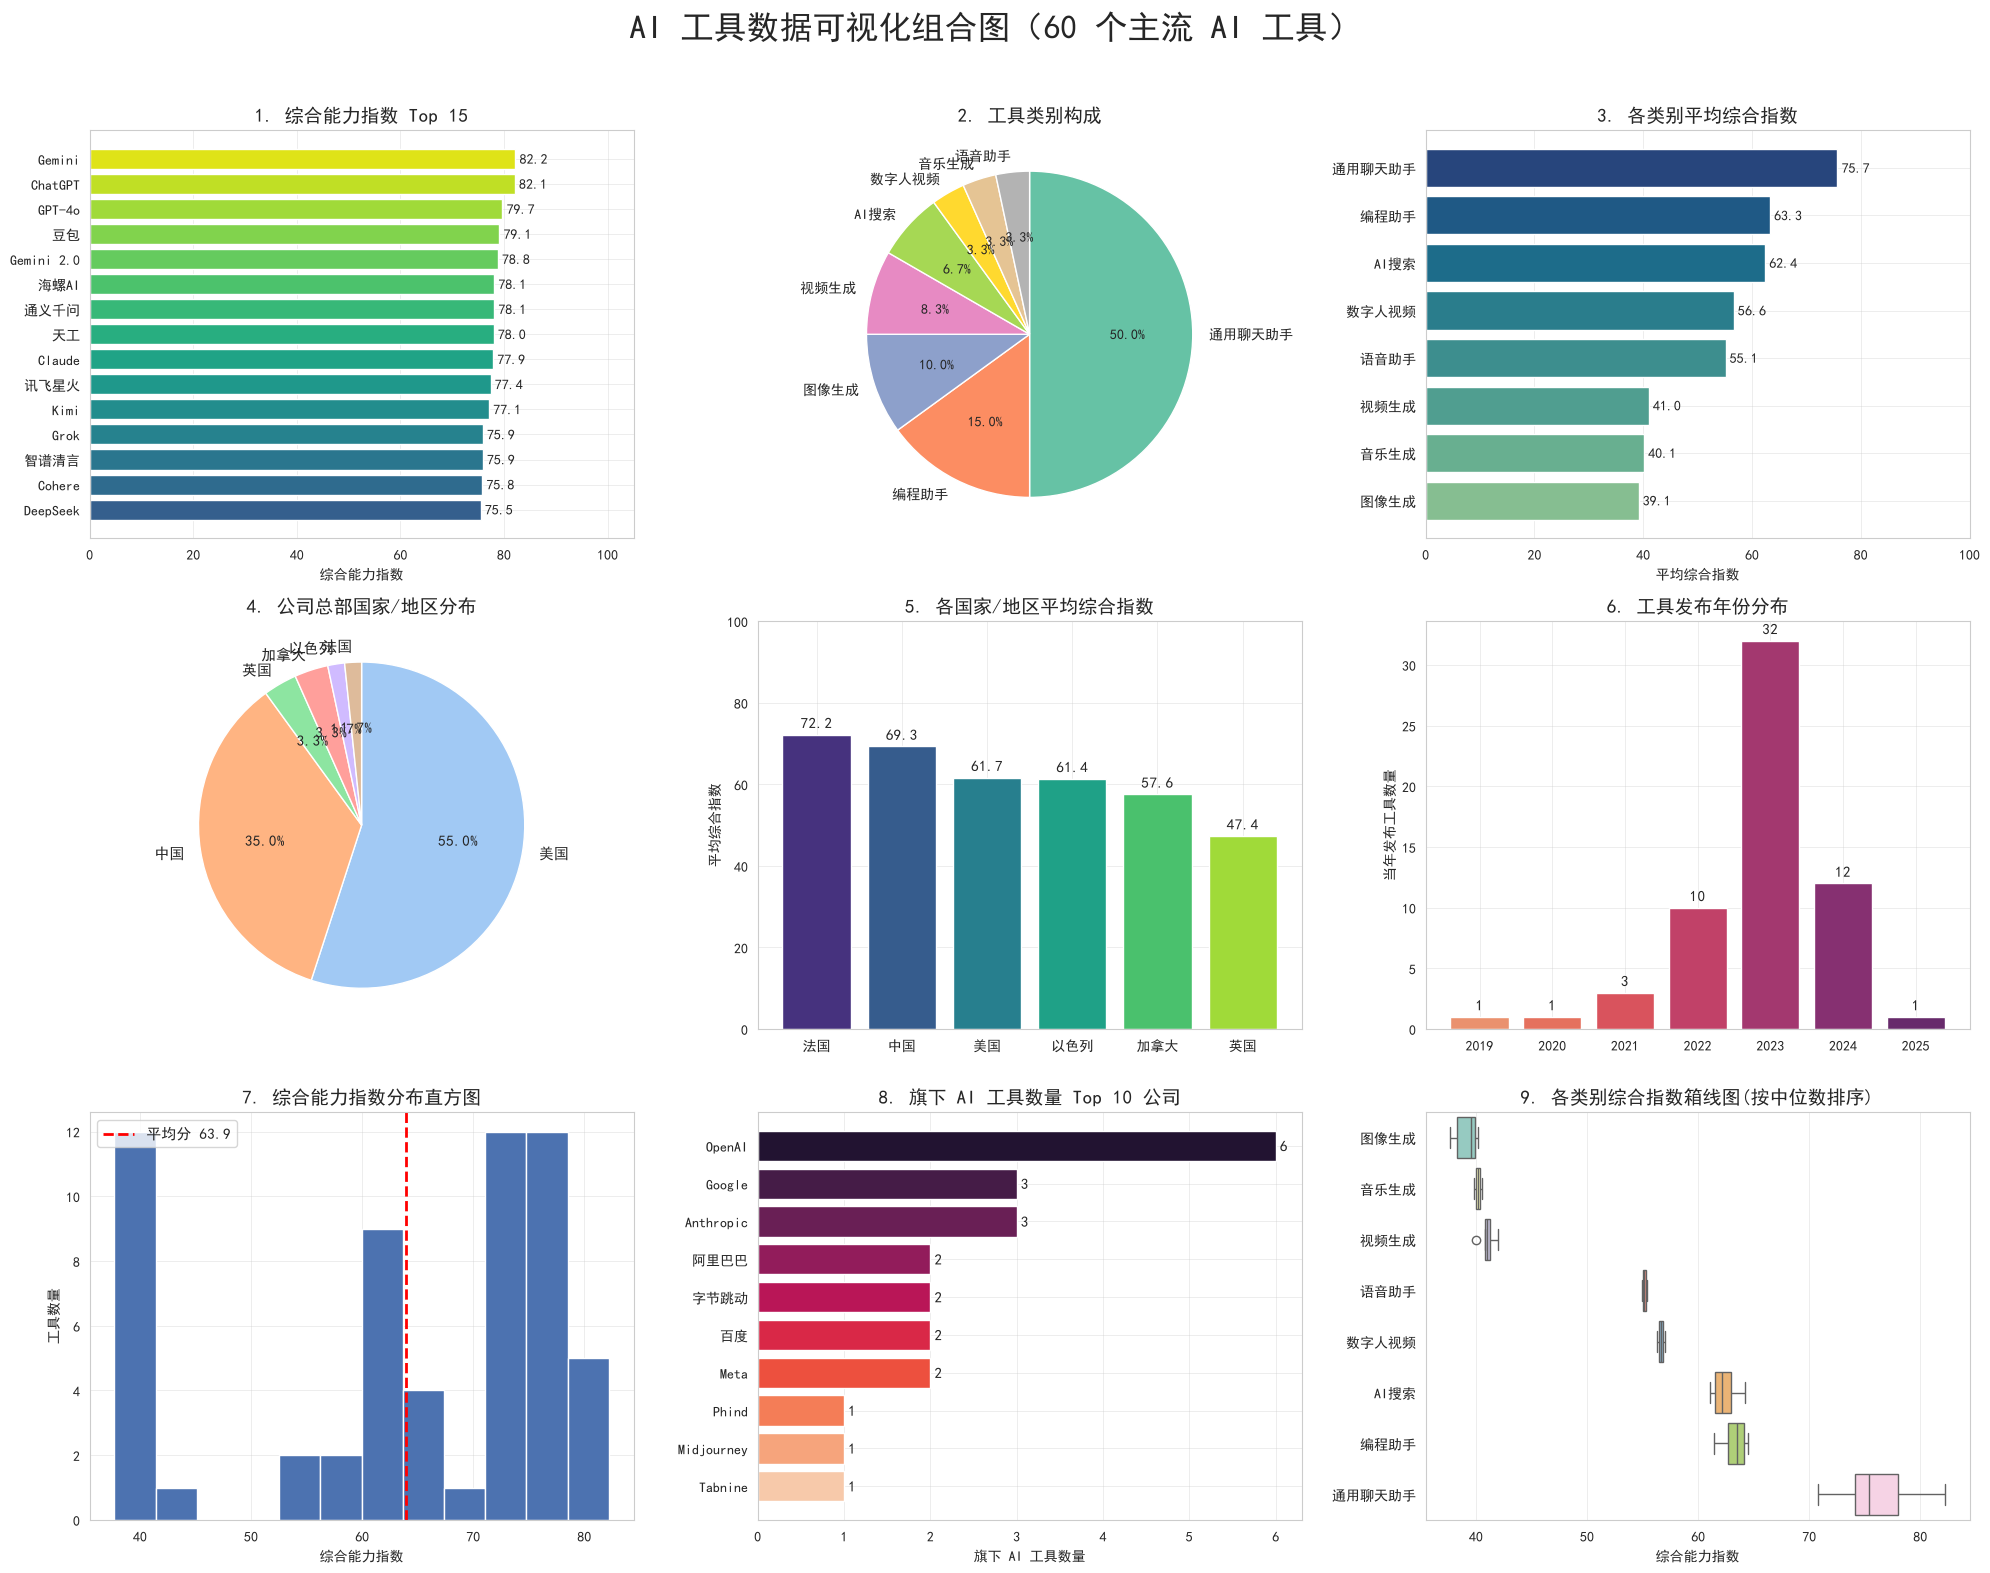

In [21]:
# ==================== AI 工具数据可视化: 3x3 九宫格组合图 (完善版) ====================
# 修复要点: 本单元格自己重新读取并清洗数据, 不再依赖前面单元格的 df 状态,
#           无论内核是刚启动还是 df 是旧缓存, 单独运行本单元格都不会再报 KeyError

sns.set_style('whitegrid')                                        # 设置 seaborn 白色网格背景风格, 图表更精美
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']   # 指定中文字体(必须放在 set_style 之后, 否则会被覆盖)
plt.rcParams['font.family'] = 'sans-serif'                        # 全局使用无衬线字体族
plt.rcParams['axes.unicode_minus'] = False                        # 修复中文环境下负号显示为方块的问题

COL_NAME = '工具名称 Tool_Name'                                    # 列名简写: 工具名称
COL_CAT = '工具类别 Tool_Category'                                 # 列名简写: 工具类别
COL_COMP = '所属公司 Company'                                      # 列名简写: 所属公司
COL_CTY = '公司总部国家 Company_Country'                           # 列名简写: 公司总部国家
COL_REL = '工具发布日期 Tool_Release_Date'                          # 列名简写: 工具发布日期
COL_SCORE = '综合能力指数 Overall_Score'                           # 列名简写: 综合能力指数
COL_DATE = '评测时间 Evaluation_Date'                              # 列名简写: 评测时间(仅在原始明细数据中存在)

df_plot = pd.read_csv('ai_tools_capability_ranking.csv')           # 直接从 CSV 重新读取数据, 避免内核旧缓存导致报错
if COL_DATE in df_plot.columns:                                    # 如果读到的是带评测明细的原始数据(未去重版本)
    df_plot = (df_plot.sort_values(COL_DATE)                       # 按评测时间排序
                     .drop_duplicates(subset=COL_NAME, keep='last')  # 每个工具只保留最新一期评测
                     .reset_index(drop=True))                      # 重置行索引
    df_plot = df_plot[[c for c in [COL_NAME, COL_CAT, COL_COMP,    # 只保留绘图需要的 6 个核心列
                                   COL_CTY, COL_REL, COL_SCORE] if c in df_plot.columns]]
df_plot['发布年份'] = pd.to_datetime(df_plot[COL_REL]).dt.year      # 解析发布日期并提取年份, 作为新列"发布年份"
print('绘图数据规模(行, 列):', df_plot.shape)                        # 打印绘图数据的行列数, 方便核对

fig, axes = plt.subplots(3, 3, figsize=(20, 16))                   # 创建 3行x3列 共 9 个子图, 画布 20x16 英寸
fig.suptitle('AI 工具数据可视化组合图（60 个主流 AI 工具）',          # 设置整张组合图的总标题
             fontsize=24, fontweight='bold', y=0.98)               # 字号 24、加粗、位于画布顶部 98% 处

# ---------- 子图1 (第1行第1列): 综合能力指数 Top 15 (横向条形图) ----------
ax = axes[0, 0]                                                    # 选中第 1 行第 1 列的子图
top15 = df_plot.nlargest(15, COL_SCORE).sort_values(COL_SCORE)     # 取综合指数最高的前 15 个工具并升序排列, 第 1 名在最上方
bars = ax.barh(top15[COL_NAME], top15[COL_SCORE],                  # y 轴: 工具名称; x 轴: 综合能力指数
               color=plt.cm.viridis(np.linspace(0.3, 0.95, 15)))   # viridis 色板生成 15 个渐变色(分数越高颜色越深)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)             # 在每根条形末端标注具体数值, 排名一目了然
ax.set_xlim(0, 105)                                                # x 轴延伸到 105, 给数值标注留出空间
ax.set_xlabel('综合能力指数')                                       # x 轴名称
ax.set_title('1. 综合能力指数 Top 15', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图2 (第1行第2列): 工具类别构成 (饼图) ----------
ax = axes[0, 1]                                                    # 选中第 1 行第 2 列的子图
cat_counts = df_plot[COL_CAT].value_counts()                       # 统计每个类别的工具数量
ax.pie(cat_counts.values,                                          # 饼图数值: 各类别工具数量
       labels=cat_counts.index,                                    # 每块扇区的标签: 类别名
       autopct='%.1f%%',                                           # 在扇区上自动标注百分比(保留 1 位小数)
       colors=sns.color_palette('Set2', len(cat_counts)),          # Set2 柔和色板, 每个类别一个颜色
       textprops={'fontsize': 10},                                 # 设置标签文字大小为 10
       startangle=90, counterclock=False)                          # 从 12 点钟方向顺时针开始画, 视觉更规范
ax.set_title('2. 工具类别构成', fontsize=14, fontweight='bold')     # 子图标题

# ---------- 子图3 (第1行第3列): 各类别平均综合指数 (横向条形图) ----------
ax = axes[0, 2]                                                    # 选中第 1 行第 3 列的子图
cat_mean = df_plot.groupby(COL_CAT)[COL_SCORE].mean().sort_values()  # 按类别分组求平均指数并升序排列
bars = ax.barh(cat_mean.index, cat_mean.values,                    # y 轴: 类别名; x 轴: 平均指数
               color=sns.color_palette('crest', len(cat_mean)))    # crest 青绿渐变色板
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)             # 标注各类别的平均分数值
ax.set_xlim(0, 100)                                                # x 轴固定 0-100, 对应指数满分区间
ax.set_xlabel('平均综合指数')                                       # x 轴名称
ax.set_title('3. 各类别平均综合指数', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图4 (第2行第1列): 公司总部国家/地区分布 (饼图) ----------
ax = axes[1, 0]                                                    # 选中第 2 行第 1 列的子图
cty_counts = df_plot[COL_CTY].value_counts()                       # 统计各国家/地区的工具数量
ax.pie(cty_counts.values,                                          # 饼图数值: 各国工具数量
       labels=cty_counts.index,                                    # 扇区标签: 国家/地区名
       autopct='%.1f%%',                                           # 自动标注百分比
       colors=sns.color_palette('pastel', len(cty_counts)),        # pastel 柔和粉彩色板
       textprops={'fontsize': 11},                                 # 标签文字大小 11
       startangle=90, counterclock=False)                          # 从 12 点钟方向顺时针开始画
ax.set_title('4. 公司总部国家/地区分布', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图5 (第2行第2列): 各国家/地区平均综合指数 (柱状图) ----------
ax = axes[1, 1]                                                    # 选中第 2 行第 2 列的子图
cty_mean = df_plot.groupby(COL_CTY)[COL_SCORE].mean().sort_values(ascending=False)  # 按国家分组求平均并降序排列
bars = ax.bar(cty_mean.index, cty_mean.values,                     # x 轴: 国家名; y 轴: 平均指数
              color=sns.color_palette('viridis', len(cty_mean)))   # viridis 色板
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=11)             # 在柱顶标注平均分数值
ax.set_ylim(0, 100)                                                # y 轴固定 0-100, 对应指数满分区间
ax.set_ylabel('平均综合指数')                                       # y 轴名称
ax.set_title('5. 各国家/地区平均综合指数', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图6 (第2行第3列): 工具发布年份分布 (柱状图) ----------
ax = axes[1, 2]                                                    # 选中第 2 行第 3 列的子图
year_counts = df_plot['发布年份'].value_counts().sort_index()       # 统计每年发布的工具数并按年份排序
bars = ax.bar(year_counts.index.astype(str), year_counts.values,   # x 轴: 年份(转为字符串); y 轴: 当年工具数量
             color=sns.color_palette('flare', len(year_counts)))   # flare 红橙渐变色板
ax.bar_label(bars, padding=3, fontsize=11)                         # 在柱顶标注每年的工具数量
ax.set_ylabel('当年发布工具数量')                                    # y 轴名称
ax.set_title('6. 工具发布年份分布', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图7 (第3行第1列): 综合能力指数分布 (直方图) ----------
ax = axes[2, 0]                                                    # 选中第 3 行第 1 列的子图
ax.hist(df_plot[COL_SCORE], bins=12, color='#4C72B0', edgecolor='white')  # 数据: 60 个工具的综合指数, 分 12 个桶, 白色描边
mean_val = df_plot[COL_SCORE].mean()                               # 计算全部工具的平均分
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,     # 画一条红色虚线竖线标出平均分位置
           label=f'平均分 {mean_val:.1f}')                         # 图例文字显示平均分数值
ax.legend(fontsize=11)                                             # 显示图例
ax.set_xlabel('综合能力指数')                                       # x 轴名称
ax.set_ylabel('工具数量')                                           # y 轴名称
ax.set_title('7. 综合能力指数分布直方图', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图8 (第3行第2列): 旗下工具数量 Top 10 公司 (横向条形图) ----------
ax = axes[2, 1]                                                    # 选中第 3 行第 2 列的子图
comp_counts = df_plot[COL_COMP].value_counts().head(10).sort_values()  # 统计各公司旗下工具数, 取前 10 并升序排列
bars = ax.barh(comp_counts.index, comp_counts.values,              # y 轴: 公司名; x 轴: 旗下工具数量
               color=sns.color_palette('rocket_r', len(comp_counts)))  # rocket_r 紫红渐变色板
ax.bar_label(bars, padding=3, fontsize=11)                         # 在条形末端标注工具数量
ax.set_xlabel('旗下 AI 工具数量')                                   # x 轴名称
ax.set_title('8. 旗下 AI 工具数量 Top 10 公司', fontsize=14, fontweight='bold')  # 子图标题

# ---------- 子图9 (第3行第3列): 各类别综合指数箱线图 (按中位数排序) ----------
ax = axes[2, 2]                                                    # 选中第 3 行第 3 列的子图
order = df_plot.groupby(COL_CAT)[COL_SCORE].median().sort_values().index  # 计算各类别中位数并排序, 作为箱线图顺序
sns.boxplot(data=df_plot, y=COL_CAT, x=COL_SCORE,                  # 数据源: y 轴类别, x 轴指数
            order=order, hue=COL_CAT, hue_order=order,             # 按中位数从低到高排列各类别(新版 seaborn 需显式指定 hue)
            palette='Set3', legend=False, ax=ax)                   # Set3 多彩色板; 不显示冗余图例; 绘制到当前子图
ax.set_xlabel('综合能力指数')                                       # x 轴名称
ax.set_ylabel('')                                                  # y 轴已有类别名, 不再重复设置名称
ax.set_title('9. 各类别综合指数箱线图(按中位数排序)', fontsize=14, fontweight='bold')  # 子图标题

plt.tight_layout(rect=[0, 0, 1, 0.96])                             # 自动调整子图间距, 顶部留 4% 给总标题
plt.savefig('AI工具数据可视化组合图.png',                          # 将组合图保存为 PNG 文件
            dpi=150, bbox_inches='tight')                          # 分辨率 150 dpi 高清输出, 裁掉四周空白
plt.show()                                                         # 在 notebook 中显示组合图